In [ ]:
 !nvidia-smi

Sat Jun 13 07:16:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

%pip install ultralytics
%pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
from collections import defaultdict
from itertools import product

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import torch
import gc
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# =====================================================
# GOOGLE DRIVE ROOT
# =====================================================

DRIVE_ROOT = "/content/drive/MyDrive/riil-dataset-skripsi/tuning-checkpoint/yolov8"

# =====================================================
# SAVE DIRECTORY
# =====================================================

GRID_PROJECT = f"{DRIVE_ROOT}/focused_grid_search"
FINAL_PROJECT = f"{DRIVE_ROOT}/final_optimized"

os.makedirs(GRID_PROJECT, exist_ok=True)
os.makedirs(FINAL_PROJECT, exist_ok=True)

# =====================================================
# DATASET CONFIG
# =====================================================

DATA_YAML = "/content/drive/MyDrive/riil-dataset-skripsi/skripsi-v5/v8/data.yaml"

# =====================================================
# BASE MODEL
# =====================================================

BASE_MODEL = "/content/drive/MyDrive/riil-dataset-skripsi/models/baseline/yolov8.pt"

# =====================================================
# FIXED HYPERPARAMETERS
# =====================================================

EPOCHS = 100
OPTIMIZER = "AdamW"
PATIENCE = 50
LR0 = 0.001

# =====================================================
# FOCUSED GRID SEARCH SPACE
# =====================================================

batch_sizes = [8, 16, 32]
img_sizes = [832, 1088]

# Create Combination

In [ ]:
all_combinations = list(product(
    batch_sizes,
    img_sizes
))

print("=" * 60)
print("FOCUSED GRID SEARCH")
print("=" * 60)

print(f"Total combinations: {len(all_combinations)}")

# Result Storage

In [ ]:
results_csv = f"{GRID_PROJECT}/focused_grid_search_results.csv"

# LOAD PREVIOUS RESULTS IF EXIST
if os.path.exists(results_csv):
    df_existing = pd.read_csv(results_csv)
    results_list = df_existing.to_dict('records')

    completed_experiments = set(
        zip(df_existing.batch, df_existing.imgsz)
    )

    print(f"Loaded previous results: {len(df_existing)}")
else:
    results_list = []
    completed_experiments = set()

# Focused Grid Search Loop

In [ ]:
for idx, (batch, imgsz) in enumerate(all_combinations):

    # ==========================================
    # SKIP COMPLETED EXPERIMENT
    # ==========================================

    if (batch, imgsz) in completed_experiments:
        print(f"SKIP batch={batch}, imgsz={imgsz} (already done)")
        continue

    print("\n" + "=" * 60)
    print(f"EXPERIMENT {idx+1}/{len(all_combinations)}")
    print("=" * 60)

    print(f"batch : {batch}")
    print(f"imgsz : {imgsz}")

    run_name = f"batch_{batch}_imgsz_{imgsz}"

    run_dir = f"{GRID_PROJECT}/{run_name}"

    # ==========================================
    # LOAD MODEL
    # ==========================================

    model = YOLO(BASE_MODEL)

    # ==========================================
    # CHECK RESUME
    # ==========================================

    last_checkpoint = f"{run_dir}/weights/last.pt"

    try:

        if os.path.exists(last_checkpoint):

            print("RESUMING TRAINING...")

            model = YOLO(last_checkpoint)

            results = model.train(
                resume=True
            )

        else:

            print("START NEW TRAINING...")

            results = model.train(

                data=DATA_YAML,

                imgsz=imgsz,
                epochs=EPOCHS,
                batch=batch,

                optimizer=OPTIMIZER,
                patience=0,

                lr0=LR0,

                val=True,
                verbose=False,
                plots=False,

                project=GRID_PROJECT,
                name=run_name,

                save=True,
                save_period=5,

                exist_ok=True
            )

        # ==========================================
        # VALIDATION
        # ==========================================

        metrics = model.val(
            data=DATA_YAML,
            split='val',
            imgsz=imgsz,
            verbose=False
        )

        precision = metrics.box.mp
        recall = metrics.box.mr
        map50 = metrics.box.map50
        map5095 = metrics.box.map

        # ==========================================
        # OBJECTIVE SCORE
        # ==========================================

        f1 = (2 * precision * recall) / (precision + recall + 1e-9)

        score = (
            0.5 * f1 +
            0.3 * recall +
            0.2 * map50
        )

        # ==========================================
        # SAVE RESULTS
        # ==========================================

        results_list.append({

            "batch": batch,
            "imgsz": imgsz,

            "precision": precision,
            "recall": recall,
            "f1": f1,

            "map50": map50,
            "map50_95": map5095,

            "score": score
        })

        df = pd.DataFrame(results_list)

        df = df.sort_values(
            by="score",
            ascending=False
        )

        df.to_csv(results_csv, index=False)

        print("\nRESULT")
        print(f"Precision  : {precision:.4f}")
        print(f"Recall     : {recall:.4f}")
        print(f"F1         : {f1:.4f}")
        print(f"mAP50      : {map50:.4f}")
        print(f"mAP50-95   : {map5095:.4f}")
        print(f"Score      : {score:.4f}")

    except Exception as e:

        print(f"ERROR TRAINING batch={batch} imgsz={imgsz}")
        print(e)

    finally:

        del model

        gc.collect()
        torch.cuda.empty_cache()

# Final Results

In [ ]:
df = pd.read_csv(results_csv)

df = df.sort_values(
    by="score",
    ascending=False
)

print("\n" + "=" * 60)
print("FINAL GRID SEARCH RESULTS")
print("=" * 60)

print(df)

best_params = df.iloc[0]

print("\n===== BEST PARAMS =====")

print(f"batch : {best_params['batch']}")
print(f"imgsz : {best_params['imgsz']}")

# Final Training

In [ ]:
final_run_name = "best_model"

final_run_dir = f"{FINAL_PROJECT}/{final_run_name}"

last_checkpoint = f"{final_run_dir}/weights/last.pt"

# =====================================================
# LOAD MODEL
# =====================================================

if os.path.exists(last_checkpoint):

    print("RESUMING FINAL TRAINING...")

    final_model = YOLO(last_checkpoint)

    results = final_model.train(
        resume=True
    )

else:

    print("START FINAL TRAINING...")

    final_model = YOLO(BASE_MODEL)

    results = final_model.train(

        data=DATA_YAML,

        imgsz=int(best_params['imgsz']),
        epochs=EPOCHS,
        batch=int(best_params['batch']),

        optimizer=OPTIMIZER,
        patience=PATIENCE,
        lr0=LR0,

        val=True,
        plots=True,

        project='final_optimized',
        name='best_model/training',

        save=True,
        save_period=5,

        exist_ok=True
    )

START FINAL TRAINING...
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/riil-dataset-skripsi/skripsi-v5/v8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1088, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/riil-dataset-skripsi/models/baseline/yolov8.pt, momentum=0.937, m

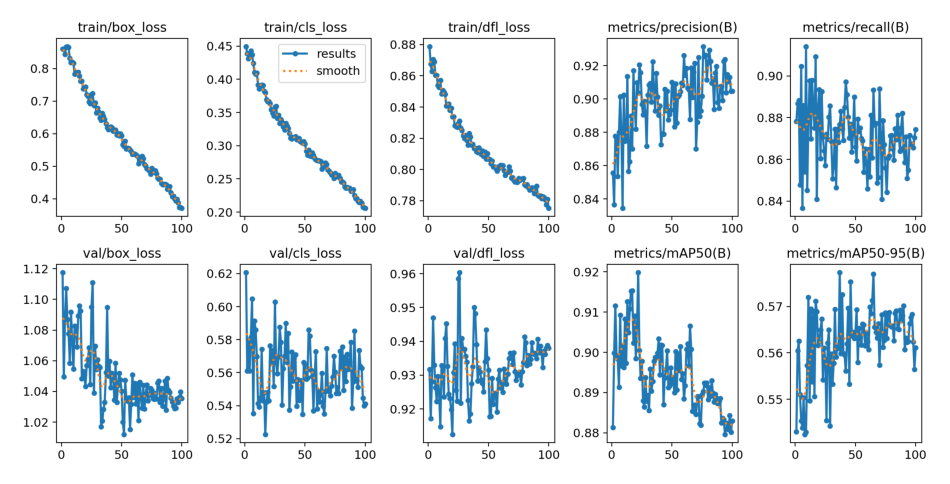

In [ ]:
img = cv2.imread('/content/runs/detect/final_optimized/best_model/training/results.png')
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Load Best Model

In [ ]:
BEST_MODEL_PATH = "/content/drive/MyDrive/riil-dataset-skripsi/tuning-checkpoint/yolov8/focused_grid_search/batch_16_imgsz_1088/weights/best.pt"

v8_best_model = YOLO(BEST_MODEL_PATH)

# Validate Model

In [ ]:
validate_metrics = v8_best_model.val(
    data=DATA_YAML,
    split='val',
    imgsz=1088,
    save_json=True,
    visualize=True,
    plots=True,
    project='final_optimized',
    name='best_model/validation',
)

# ============================================================
# 3. PRINT METRICS VALIDATION
# ============================================================
print("===== VALIDATION RESULT =====")
print("mAP50      :", validate_metrics.box.map50)
print("mAP50-95   :", validate_metrics.box.map)
print("Precision  :", validate_metrics.box.mp)
print("Recall     :", validate_metrics.box.mr)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 170.3±14.9 MB/s, size: 337.2 KB)
val: Scanning /content/drive/MyDrive/riil-dataset-skripsi/skripsi-v5/v8/valid/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.8s/it 5.5s
                   all         35        424      0.899      0.883      0.901      0.576
             no_gloves         24         87      0.763      0.703      0.741      0.337
            no_hairnet         18         25      0.879          1      0.973      0.789
               no_mask         20         31      0.929      0.935      0.931      0.534
            yes_gloves         19         75      0.891      0.787      0.843       0.49

In [ ]:
img1 = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/BoxF1_curve.png')
img2 = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/BoxPR_curve.png')
img3 = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/BoxP_curve.png')
img4 = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/BoxR_curve.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Validation F1-Curve')

axes[0, 1].imshow(img2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Validation PR Curve')

axes[1, 0].imshow(img3)
axes[1, 0].axis('off')
axes[1, 0].set_title('Validation Precision Curve')

axes[1, 1].imshow(img4)
axes[1, 1].axis('off')
axes[1, 1].set_title('Validation Recall Curve')

plt.tight_layout()
plt.show()

In [ ]:
conf_matrix_val = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/confusion_matrix.png')
conf_matrix_nr_val = cv2.imread('/content/runs/detect/final_optimized/best_model/validation/confusion_matrix_normalized.png')

conf_matrix_val = cv2.cvtColor(conf_matrix_val, cv2.COLOR_BGR2RGB)
conf_matrix_nr_val = cv2.cvtColor(conf_matrix_nr_val, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(conf_matrix_val); axes[0].axis('off'); axes[0]
axes[1].imshow(conf_matrix_nr_val); axes[1].axis('off'); axes[1]
plt.tight_layout()
plt.show()

# Test Model

In [ ]:
# ================================
# TEST CONFIG
# ================================
IOU_NMS    = 0.7
IOU_MATCH  = 0.5

# ================================
# TESTING (YOLO BUILT-IN)
# ================================
metrics = v8_best_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=1088,
    iou=IOU_NMS,
    verbose=True,
    save_json=True,
    plots=True,
    project='final_optimized',
    name='best_model/testing',
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 167.2±26.2 MB/s, size: 329.6 KB)
val: Scanning /content/drive/MyDrive/riil-dataset-skripsi/skripsi-v5/v8/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 12.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.4s
                   all         35        359      0.889      0.894      0.885      0.571
             no_gloves         20         61      0.817       0.82       0.81      0.418
            no_hairnet         22         40      0.983       0.95      0.945      0.816
               no_mask         24         35       0.82      0.914      0.849      0.407
            yes_gloves         22         81      0.838      0.728      0.763      0.444
           yes_hairnet         32        115      0.982      0.991      0.995     

In [ ]:
# ================================
# AMBIL GAMBAR TEST
# ================================
def get_test_images():
    from pathlib import Path

    test_path = Path("/content/drive/MyDrive/riil-dataset-skripsi/skripsi-v5/v8/test/images")

    print("Resolved test path:", test_path)

    images = list(test_path.glob("*.jpg")) + \
             list(test_path.glob("*.png")) + \
             list(test_path.glob("*.jpeg"))

    print("Jumlah gambar:", len(images))

    return sorted(images)


# ================================
# LOAD GT (CLS + BBOX)
# ================================
def load_gt_boxes(label_path, img_w, img_h):
    boxes = []

    if not Path(label_path).exists():
        return boxes

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        cls, x, y, w, h = map(float, parts)

        x1 = (x - w/2) * img_w
        y1 = (y - h/2) * img_h
        x2 = (x + w/2) * img_w
        y2 = (y + h/2) * img_h

        boxes.append((int(cls), [x1, y1, x2, y2]))

    return boxes

In [ ]:
# ================================
# IOU
# ================================
def bbox_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

# ================================
# MATCHING
# ================================
def match_detections(pred_boxes, gt_boxes, iou_threshold=IOU_MATCH):

    TP_c = defaultdict(int)
    FP_c = defaultdict(int)
    FN_c = defaultdict(int)

    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return TP_c, FP_c, FN_c

    if len(pred_boxes) == 0:
        for cls, _ in gt_boxes:
            FN_c[cls] += 1
        return TP_c, FP_c, FN_c

    if len(gt_boxes) == 0:
        for cls, _ in pred_boxes:
            FP_c[cls] += 1
        return TP_c, FP_c, FN_c

    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)))

    for i, (cls_p, box_p) in enumerate(pred_boxes):
        for j, (cls_g, box_g) in enumerate(gt_boxes):
            if cls_p != cls_g:
                iou_matrix[i, j] = 0
            else:
                iou_matrix[i, j] = bbox_iou(box_p, box_g)

    matched_pred = set()
    matched_gt = set()

    indices = np.dstack(np.unravel_index(
        np.argsort(iou_matrix.ravel())[::-1],
        iou_matrix.shape
    ))[0]

    for i, j in indices:
        if i in matched_pred or j in matched_gt:
            continue

        if iou_matrix[i, j] < iou_threshold:
            break

        cls = gt_boxes[j][0]
        TP_c[cls] += 1

        matched_pred.add(i)
        matched_gt.add(j)

    # FP
    for i, (cls, _) in enumerate(pred_boxes):
        if i not in matched_pred:
            FP_c[cls] += 1

    # FN
    for j, (cls, _) in enumerate(gt_boxes):
        if j not in matched_gt:
            FN_c[cls] += 1

    return TP_c, FP_c, FN_c

In [ ]:
# ================================
# EVALUASI TEST
# ================================
print("\n===== TESTING MANUAL MODEL YOLOv5 =====")

test_images = get_test_images()

TP_total = defaultdict(int)
FP_total = defaultdict(int)
FN_total = defaultdict(int)

for img_path in tqdm(test_images):

    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]

    label_path = str(img_path).replace("/images/", "/labels/").replace(".jpg", ".txt")

    gt_boxes = load_gt_boxes(label_path, w, h)

    results = v8_best_model.predict(str(img_path), imgsz=1088, iou=IOU_NMS, verbose=True)
    boxes = results[0].boxes

    pred_boxes = []
    if boxes is not None:
        for b, c in zip(boxes.xyxy.cpu().numpy(), boxes.cls.cpu().numpy()):
            pred_boxes.append((int(c), b.tolist()))

    TP_c, FP_c, FN_c = match_detections(pred_boxes, gt_boxes, IOU_MATCH)

    for k in TP_c:
        TP_total[k] += TP_c[k]
    for k in FP_c:
        FP_total[k] += FP_c[k]
    for k in FN_c:
        FN_total[k] += FN_c[k]

In [ ]:
# ================================
# OUTPUT PER CLASS
# ================================
print("\n===== HASIL PER CLASS =====")

all_classes = set(TP_total.keys()) | set(FP_total.keys()) | set(FN_total.keys())

for cls in sorted(all_classes):
    TP = TP_total[cls]
    FP = FP_total[cls]
    FN = FN_total[cls]

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0

    print(f"\nClass {cls}")
    print(f"TP: {TP} | FP: {FP} | FN: {FN}")

# ================================
# OVERALL
# ================================
TP_sum = sum(TP_total.values())
FP_sum = sum(FP_total.values())
FN_sum = sum(FN_total.values())

print("\n===== OVERALL =====")
print(f"TP: {TP_sum} | FP: {FP_sum} | FN: {FN_sum}")

In [ ]:
img1 = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/BoxF1_curve.png')
img2 = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/BoxPR_curve.png')
img3 = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/BoxP_curve.png')
img4 = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/BoxR_curve.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Testing F1-Curve')

axes[0, 1].imshow(img2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Testing PR Curve')

axes[1, 0].imshow(img3)
axes[1, 0].axis('off')
axes[1, 0].set_title('Testing Precision Curve')

axes[1, 1].imshow(img4)
axes[1, 1].axis('off')
axes[1, 1].set_title('Testing Recall Curve')

plt.tight_layout()
plt.show()

In [ ]:
conf_matrix_val = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/confusion_matrix.png')
conf_matrix_nr_val = cv2.imread('/content/runs/detect/final_optimized/best_model/testing/confusion_matrix_normalized.png')

conf_matrix_val = cv2.cvtColor(conf_matrix_val, cv2.COLOR_BGR2RGB)
conf_matrix_nr_val = cv2.cvtColor(conf_matrix_nr_val, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(conf_matrix_val); axes[0].axis('off'); axes[0]
axes[1].imshow(conf_matrix_nr_val); axes[1].axis('off'); axes[1]
plt.tight_layout()
plt.show()